In [10]:
import requests as req
from bs4 import BeautifulSoup as bs
import pandas as pd
url = "https://lol.inven.co.kr/dataninfo/match/champTotal.php"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36 Edg/148.0.0.0"}
web = req.get(url, headers=headers)
soup = bs(web.content, 'html.parser')
list_table = soup.select(".listTable tr")
df = pd.DataFrame([t.strip().split('\n') for t in [x.text for x in list_table] ])
df.columns = df.loc[0]
raw = df.iloc[1:].copy() # .set_index('순위')
# 경기수 컬럼 추가
raw['경기수'] = raw['승리'].astype('int')
raw['패배'] = raw['패배'].astype('int')
raw['경기수'] = raw['경기수']
raw.sort_values('경기수',ascending=False)

,순위,챔피언,밴,밴순서,밴비율,픽,픽순서,픽비율,밴+픽,밴픽률,승리,패배,승률,경기수
34,34,리 신,3933,2.2,44%,2329,4.97,46%,6262,69.6%,1186,1143,50.9%,1186
112,112,이즈리얼,1229,2.78,13.7%,2190,6.86,28.2%,3419,38%,1103,1087,50.4%,1103
82,82,쓰레쉬,2703,2.32,30.2%,1607,5.26,25.5%,4310,47.9%,827,780,51.5%,827
4,4,그라가스,1393,2.53,15.6%,1637,5.3,21.5%,3030,33.7%,816,821,49.8%,816
92,92,알리스타,1469,2.8,16.4%,1623,4.67,21.6%,3092,34.4%,802,821,49.4%,802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,1,가렌,11,3.64,0.1%,19,3.68,0.2%,30,0.3%,6,13,31.6%,6
66,66,샤코,184,2.17,2.1%,21,18.81,0.2%,205,2.3%,5,16,23.8%,5
159,159,티모,0,－,0%,9,10.67,0.1%,9,0.1%,4,5,44.4%,4
89,89,아크샨,8,4.63,0.1%,5,4.8,0.1%,13,0.1%,2,3,40%,2


In [11]:
# 문자로 바꾼후 % 제거 하고 float로 데이터타입변경
raw['승률'] = raw['승률'].str.replace('%','').astype('float')

In [12]:
ori = raw.sort_values('승률', ascending=False)[['챔피언','승리','패배','경기수','승률']].copy()
total = ori[ori['경기수'] > 50][:10]
total

,챔피언,승리,패배,경기수,승률
81,신지드,82,51,82,61.7
104,요네,132,88,132,60.0
15,니코,110,78,110,58.5
118,잔나,270,198,270,57.7
93,애니,220,166,220,57.0
120,제드,161,122,161,56.9
67,세나,217,165,217,56.8
40,말자하,135,103,135,56.7
65,사일러스,327,253,327,56.4
35,리븐,67,52,67,56.3


Text(0.2, 0.4, '한글')

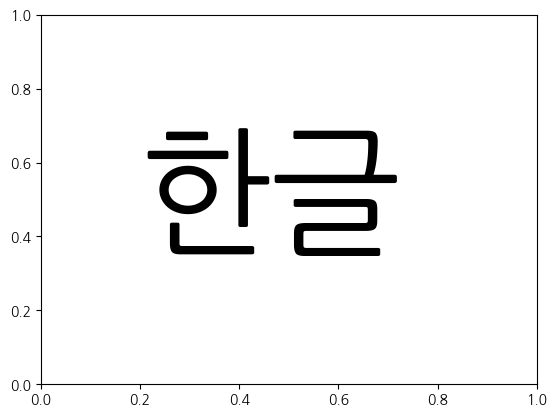

In [13]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

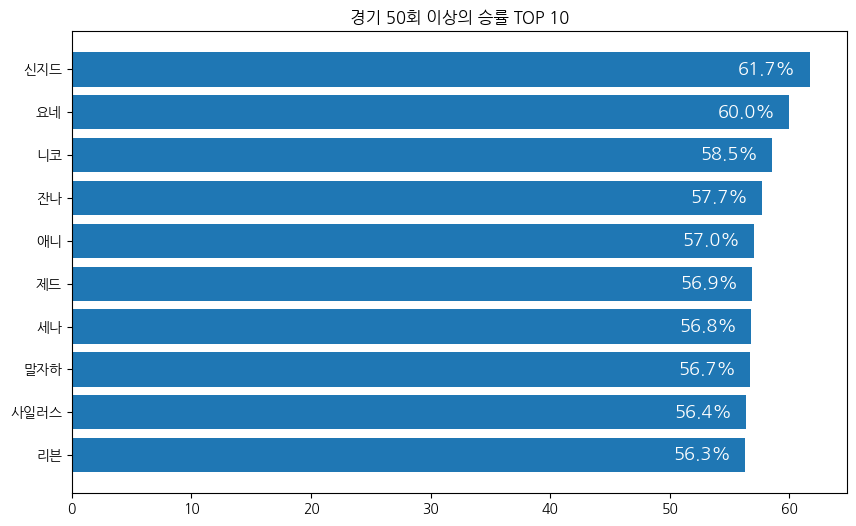

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
barh = plt.barh(total['챔피언'], total['승률'])

for b in barh:
    plt.text(b.get_width()-6, b.get_y() +0.1 + (b.get_height() /2 )  ,f'{b.get_width()}%',color="white",size=13)
    
plt.gca().invert_yaxis()
plt.title('경기 50회 이상의 승률 TOP 10')
plt.show()

In [73]:
ori2 = raw.sort_values('승률', ascending=False)[['챔피언','픽비율','밴픽률','승률','경기수']]
total2 = ori2[ori2['경기수'] > 50].copy()
total2['픽비율'] = total2['픽비율'].str.replace('%','').astype('float')
total2['밴픽률'] = total2['밴픽률'].str.replace('%','').astype('float')
total2 = total2[:20]

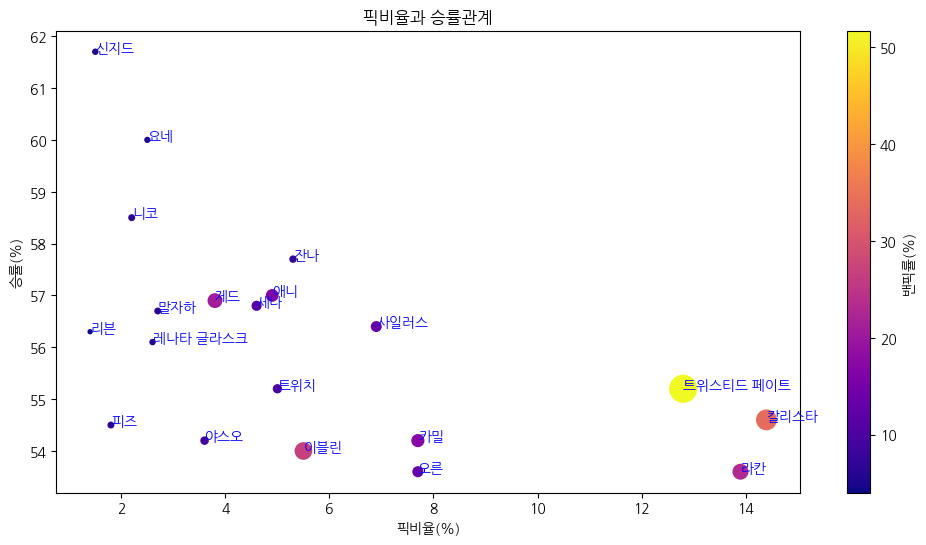

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
barh = plt.scatter(total2['픽비율'], total2['승률'], s=total2['밴픽률']**1.5 , c= total2['밴픽률'], cmap='plasma')

for i in range(len(total2)):
    plt.text( total2['픽비율'].iloc[i], total2['승률'].iloc[i] , f"{total2['챔피언'].iloc[i]}",color="blue",size=10)

plt.title('픽비율과 승률관계')
plt.xlabel('픽비율(%)')
plt.ylabel('승률(%)')
plt.colorbar(label="밴픽률(%)")
plt.show()